# Diversity by County

# Clean data
Merge the column with the data dictionary + merge multiracial categories. 

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import re
import matplotlib.pyplot as plt

In [6]:
racial_census_df = pd.read_csv('../data/racialcensusdata.csv')

In [3]:
racial_census_df.head(5)

,GEO_ID,NAME,P9_001N,P9_002N,P9_003N,P9_004N,P9_005N,P9_006N,P9_007N,P9_008N,...,P9_065N,P9_066N,P9_067N,P9_068N,P9_069N,P9_070N,P9_071N,P9_072N,P9_073N,Unnamed: 75
0,Geography,Geographic Area Name,!!Total:,!!Total:!!Hispanic or Latino,!!Total:!!Not Hispanic or Latino:,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,NaN
1,0500000US01001,"Autauga County, Alabama",58805,2117,56688,54198,41582,11352,184,873,...,0,0,0,0,0,0,0,0,0,NaN
2,0500000US01003,"Baldwin County, Alabama",231767,12686,219081,208713,186495,18001,1291,2029,...,0,0,0,0,0,0,0,0,0,NaN
3,0500000US01005,"Barbour County, Alabama",25223,1510,23713,23160,11086,11850,58,103,...,2,2,0,0,0,0,0,0,0,NaN
4,0500000US01007,"Bibb County, Alabama",22293,740,21553,20953,16442,4390,39,26,...,0,0,0,0,0,0,0,0,0,NaN


In [10]:
df_subset = racial_census_df.iloc[:, :13].copy()

In [11]:
df_subset

,GEO_ID,NAME,P9_001N,P9_002N,P9_003N,P9_004N,P9_005N,P9_006N,P9_007N,P9_008N,P9_009N,P9_010N,P9_011N
0,Geography,Geographic Area Name,!!Total:,!!Total:!!Hispanic or Latino,!!Total:!!Not Hispanic or Latino:,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...
1,0500000US01001,"Autauga County, Alabama",58805,2117,56688,54198,41582,11352,184,873,22,185,2490
2,0500000US01003,"Baldwin County, Alabama",231767,12686,219081,208713,186495,18001,1291,2029,122,775,10368
3,0500000US01005,"Barbour County, Alabama",25223,1510,23713,23160,11086,11850,58,103,0,63,553
4,0500000US01007,"Bibb County, Alabama",22293,740,21553,20953,16442,4390,39,26,9,47,600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3217,0500000US72145,"Vega Baja Municipio, Puerto Rico",54414,54012,402,353,279,31,9,11,0,23,49
3218,0500000US72147,"Vieques Municipio, Puerto Rico",8249,7586,663,653,533,47,15,3,0,55,10
3219,0500000US72149,"Villalba Municipio, Puerto Rico",22093,22008,85,80,65,3,5,1,0,6,5
3220,0500000US72151,"Yabucoa Municipio, Puerto Rico",30426,30258,168,156,115,12,1,8,2,18,12


In [13]:
# Create a dictionary mapping the current index to a clean name
new_names = {
    df_subset.columns[0]: 'GEO_ID',
    df_subset.columns[1]: 'County_Name',
    df_subset.columns[2]: 'Total_Pop',
    df_subset.columns[3]: 'Hispanic_Latino',
    df_subset.columns[4]: 'Not_Hispanic_Total',
    df_subset.columns[5]: 'One_Race_Total',
    df_subset.columns[6]: 'White_alone',
    df_subset.columns[7]: 'Black_alone',
    df_subset.columns[8]: 'AIAN_alone',   # American Indian / Alaska Native
    df_subset.columns[9]: 'Asian_alone',
    df_subset.columns[10]: 'NHPI_alone',  # Native Hawaiian / Pacific Islander
    df_subset.columns[11]: 'Other_alone',
    df_subset.columns[12]: 'Two_or_More'  # This is the multiracial category
}

# Apply the rename
df_subset = df_subset.drop(0).reset_index(drop=True)
df_subset = df_subset.rename(columns=new_names)


# Make sure the numbers are actually numbers (int) for analysis
cols_to_fix = df_subset.columns[2:]
df_subset[cols_to_fix] = df_subset[cols_to_fix].apply(pd.to_numeric)

df_subset.head()

,GEO_ID,County_Name,Total_Pop,Hispanic_Latino,Not_Hispanic_Total,One_Race_Total,White_alone,Black_alone,AIAN_alone,Asian_alone,NHPI_alone,Other_alone,Two_or_More
0,0500000US01001,"Autauga County, Alabama",58805,2117,56688,54198,41582,11352,184,873,22,185,2490
1,0500000US01003,"Baldwin County, Alabama",231767,12686,219081,208713,186495,18001,1291,2029,122,775,10368
2,0500000US01005,"Barbour County, Alabama",25223,1510,23713,23160,11086,11850,58,103,0,63,553
3,0500000US01007,"Bibb County, Alabama",22293,740,21553,20953,16442,4390,39,26,9,47,600
4,0500000US01009,"Blount County, Alabama",59134,5771,53363,51063,49764,826,188,174,11,100,2300


In [14]:
# 1. Define the columns that make up the 100% total population
race_columns = ['Hispanic_Latino', 'White_alone', 'Black_alone', 'AIAN_alone', 
                'Asian_alone', 'NHPI_alone', 'Other_alone', 'Two_or_More']

# 2. Calculate proportions by dividing the race columns by Total_Pop
df_proportions = df_subset[race_columns].div(df_subset['Total_Pop'], axis=0).round(4)

# 3. Create your new vector dataframe
df_vectors = df_subset[['GEO_ID', 'County_Name']].copy()

# 4. Store these proportions as a vector
df_vectors['race_proportion_vector'] = df_proportions.values.tolist()

# Display the first few rows to see the decimal proportions
df_vectors.head()

,GEO_ID,County_Name,race_proportion_vector
0,0500000US01001,"Autauga County, Alabama","[0.036, 0.7071, 0.193, 0.0031, 0.0148, 0.0004,..."
1,0500000US01003,"Baldwin County, Alabama","[0.0547, 0.8047, 0.0777, 0.0056, 0.0088, 0.000..."
2,0500000US01005,"Barbour County, Alabama","[0.0599, 0.4395, 0.4698, 0.0023, 0.0041, 0.0, ..."
3,0500000US01007,"Bibb County, Alabama","[0.0332, 0.7375, 0.1969, 0.0017, 0.0012, 0.000..."
4,0500000US01009,"Blount County, Alabama","[0.0976, 0.8415, 0.014, 0.0032, 0.0029, 0.0002..."


In [15]:
# 1. Calculate the sum of squares for each row in the proportions dataframe
# We square the numbers first (** 2) and then sum them horizontally (axis=1)
df_vectors['diversity_index'] = (df_proportions ** 2).sum(axis=1).round(4)

# Display to see the new concentration metric
df_vectors.head()

,GEO_ID,County_Name,race_proportion_vector,diversity_index
0,0500000US01001,"Autauga County, Alabama","[0.036, 0.7071, 0.193, 0.0031, 0.0148, 0.0004,...",0.5406
1,0500000US01003,"Baldwin County, Alabama","[0.0547, 0.8047, 0.0777, 0.0056, 0.0088, 0.000...",0.6587
2,0500000US01005,"Barbour County, Alabama","[0.0599, 0.4395, 0.4698, 0.0023, 0.0041, 0.0, ...",0.4180
3,0500000US01007,"Bibb County, Alabama","[0.0332, 0.7375, 0.1969, 0.0017, 0.0012, 0.000...",0.5845
4,0500000US01009,"Blount County, Alabama","[0.0976, 0.8415, 0.014, 0.0032, 0.0029, 0.0002...",0.7194


In [16]:
# Create a 5-digit FIPS column to match standard mapping files
df_vectors['FIPS'] = df_vectors['GEO_ID'].str[-5:]

In [17]:
# 1. Download the County boundaries (this might take a moment)
url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_5m.zip"
counties_map = gpd.read_file(url)

# 2. Join your index data to the map
# We match the 'GEOID' from the map to the 'FIPS' we just created
merged_map = counties_map.merge(df_vectors, left_on='GEOID', right_on='FIPS')

# 3. Filter for a specific state to make the map readable
# Example: Alabama (FIPS starts with '01') or Pennsylvania (starts with '42')
state_map = merged_map[merged_map['STATEFP'] == '05'] # Change '01' to '42' for PA

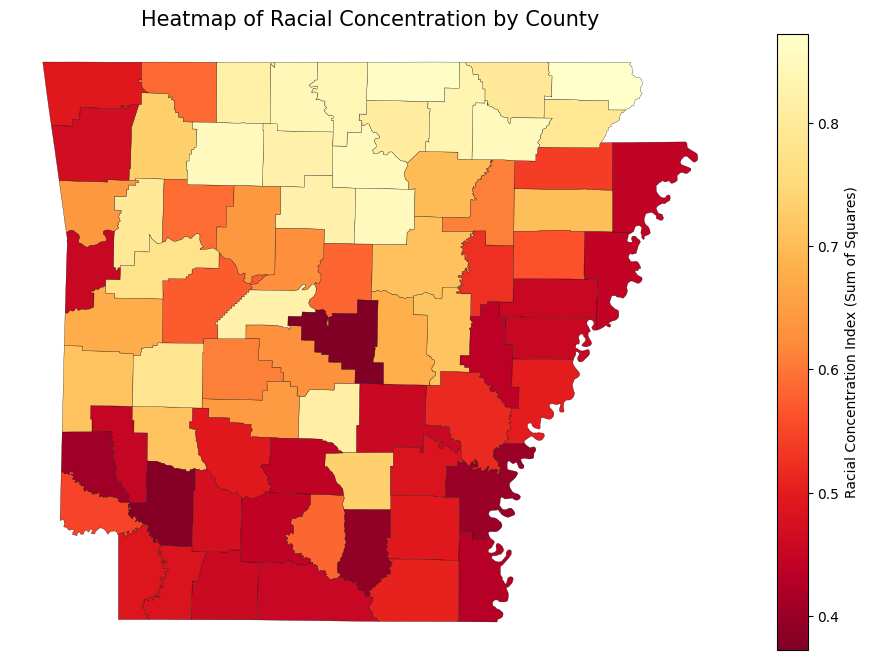

In [18]:
# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

state_map.plot(column='diversity_index', 
               cmap='YlOrRd_r',  # Yellow to Orange to Red (Higher = More Concentrated)
               legend=True,
               legend_kwds={'label': "Racial Concentration Index (Sum of Squares)"},
               ax=ax,
               edgecolor='black',
               linewidth=0.2)

ax.set_title('Heatmap of Racial Concentration by County', fontsize=15)
ax.axis('off')

plt.show()

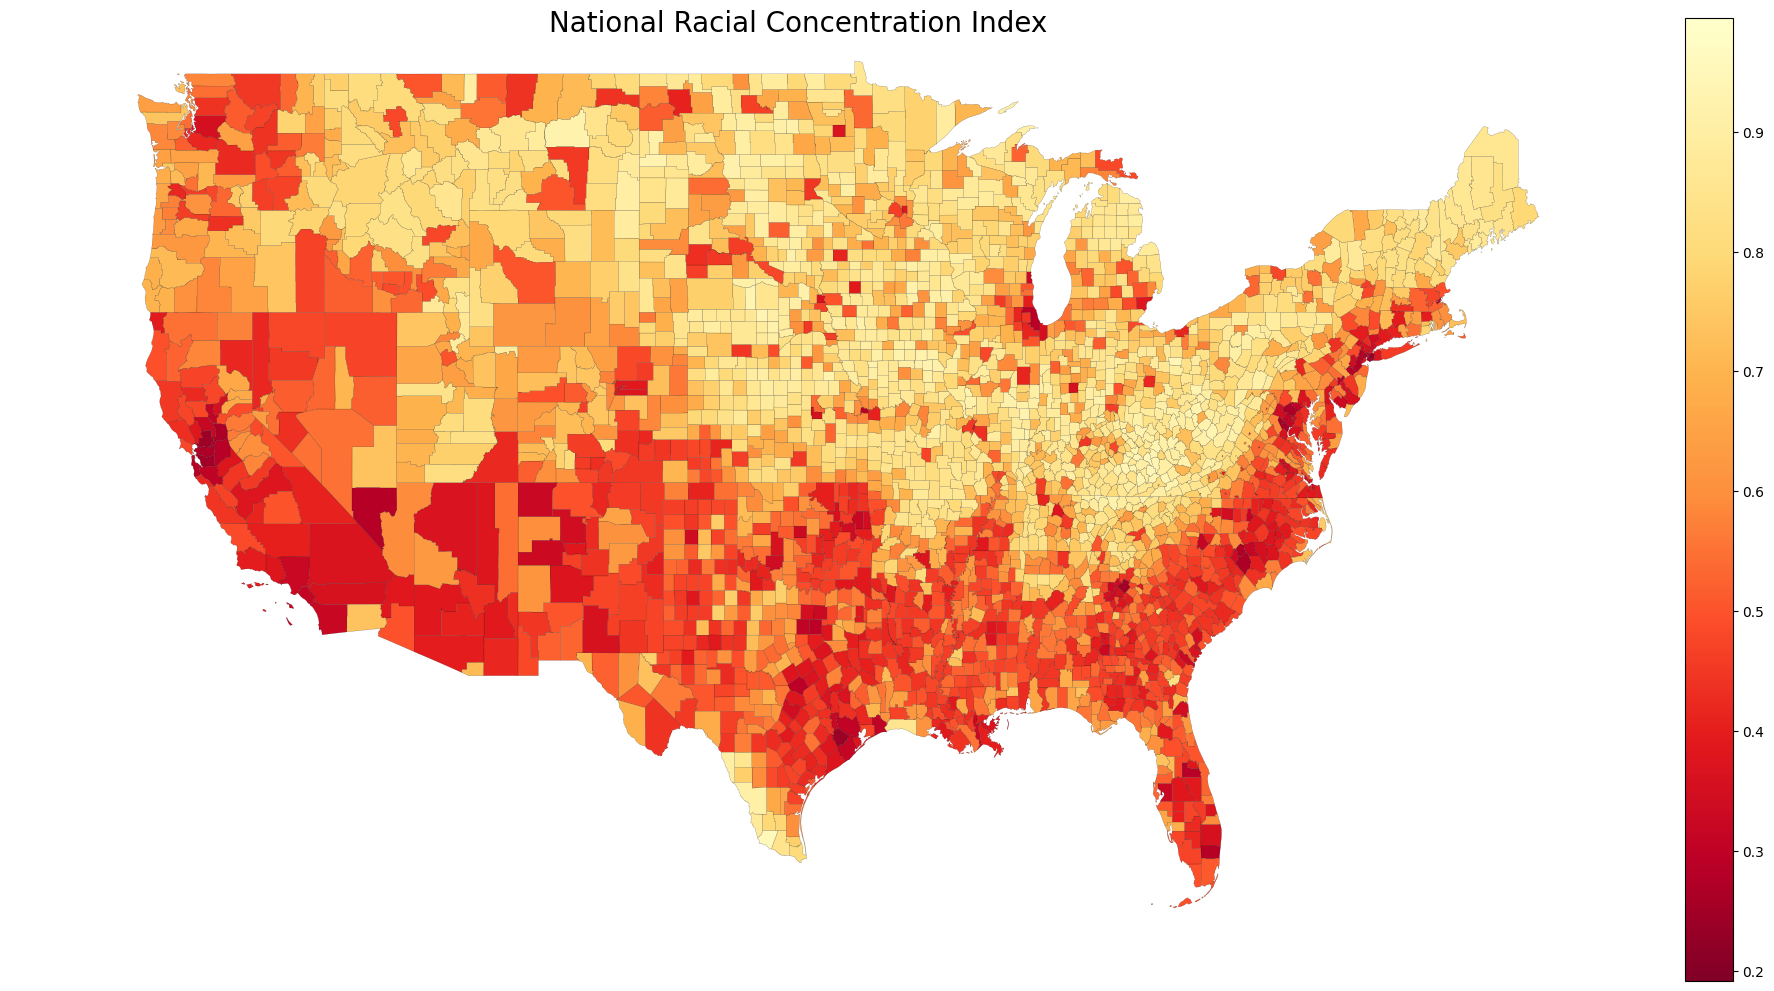

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10)) # Increase figsize for high resolution

# Plot the map
merged_map.plot(column='diversity_index', 
               cmap='YlOrRd_r', 
               legend=True,
               ax=ax,
               edgecolor='black',
               linewidth=0.1)

# ZOOM into the contiguous United States
ax.set_xlim([-130, -65]) # Longitude
ax.set_ylim([23, 50])    # Latitude

ax.set_title('National Racial Concentration Index', fontsize=20)
ax.axis('off')

plt.tight_layout()
plt.show()